<a href="https://colab.research.google.com/github/mdNotFound/100-days-of-ai-engineering/blob/main/Day_13_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

In [2]:
device="cuda" if torch.cuda.is_available() else "cpu"
print("Using device:",device)

Using device: cuda


In [3]:
def load_prices():
  try:
    import yfinance as yf
    raw=yf.download("RELIANCE.NS", start="2015-01-01", end="2026-01-01",
                    interval="1d", auto_adjust=True,progress=False)
    if raw is None or len(raw)==0:
      raise RuntimeError("empty download")

    if isinstance(raw.columns,pd.MultiIndex):
      raw.columns=raw.columns.get_level_values(0)
    raw=raw[["Open","High","Low","Close","Volume"]].dropna()
    print(f"Loaded REAL data for RELIANCE.NS: {len(raw)}rows"
          f"({raw.index.min().date()}->{raw.index.max().date()})")
    return raw
  except Exception as e:
    print("yfinance unavailable (", repr(e),") -> using synthetic fallback")
    return None
data_raw=load_prices()
data_raw.head()

Loaded REAL data for RELIANCE.NS: 2716rows(2015-01-01->2025-12-31)


Price,Open,High,Low,Close,Volume
Date,,,,,
2015-01-01,188.784602,189.998713,188.220131,189.125397,2963643
2015-01-02,189.167989,190.861371,188.358586,188.624832,7331366
2015-01-05,188.507633,189.764358,186.185896,186.558655,10103941
2015-01-06,185.312606,185.951611,177.218481,178.091797,18627980
2015-01-07,178.304828,182.926990,178.283529,181.968475,20720312


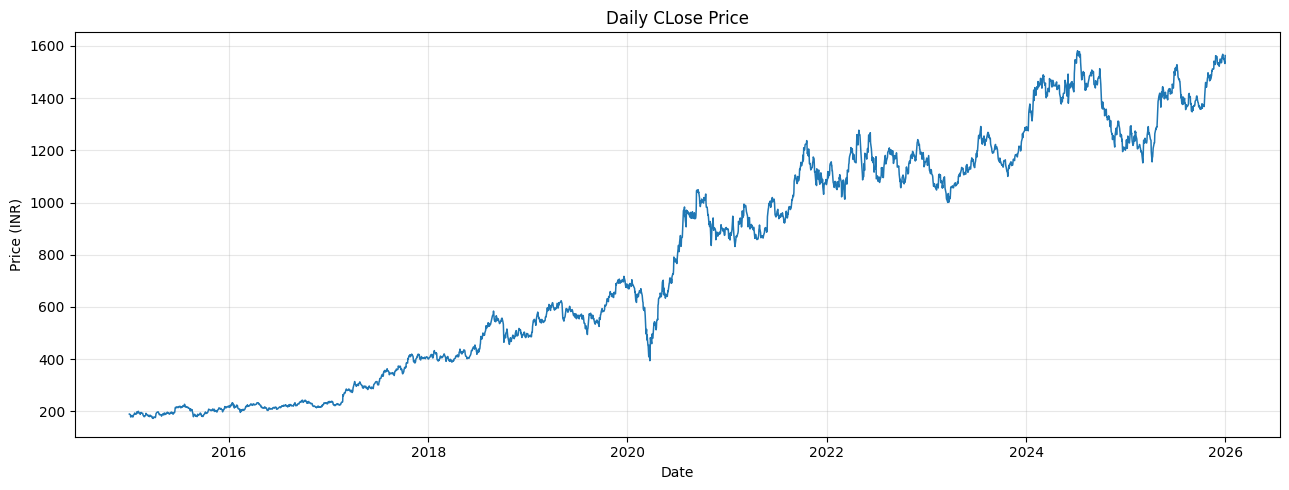

In [4]:
fix,ax=plt.subplots(figsize=(13,5))
ax.plot(data_raw.index,data_raw["Close"],lw=1.1)
ax.set_title("Daily CLose Price")
ax.set_xlabel("Date"); ax.set_ylabel("Price (INR)")
ax.grid(alpha=0.3)
plt.tight_layout();plt.show()

In [5]:
LOOKBACK=30
HORIZON=1

In [6]:
FEATURES=["Open","High","Low"]
TARGET="CLose"

In [7]:
def make_windows(feature_matrix,target_vector,lookback):
  X,y=[],[]
  for i in range(lookback,len(feature_matrix)):
    X.append(feature_matrix[i-lookback:i])
    y.append(target_vector[i])
  return np.array(X,dtype=np.float32),np.array(y,dtype=np.float32)

In [8]:
TARGET = "Close"
feature_matrix = data_raw[FEATURES].values.astype(np.float32)
target_vector = data_raw[TARGET].values.astype(np.float32).reshape(-1,1)
feature_matrix

array([[ 188.7846 ,  189.99872,  188.22014],
       [ 189.16798,  190.86137,  188.35858],
       [ 188.50763,  189.76436,  186.1859 ],
       ...,
       [1547.7439 , 1550.9292 , 1536.4958 ],
       [1539.8802 , 1546.4498 , 1530.7225 ],
       [1533.9078 , 1569.7422 , 1533.9078 ]], dtype=float32)

In [9]:
feature_matrix.shape

(2716, 3)

In [10]:
target_vector.shape

(2716, 1)

In [11]:
X_all,y_all=make_windows(feature_matrix,target_vector,LOOKBACK)
print("X_all shape",X_all.shape)
print("y_all shape",y_all.shape)

X_all shape (2686, 30, 3)
y_all shape (2686, 1)


In [12]:
n=len(X_all)
i_train=int(n*0.80)
i_val=int(n*(0.80+0.1))
X_train,y_train=X_all[:i_train],y_all[:i_train]
X_val,y_val=X_all[i_train:i_val],y_all[i_train:i_val]
X_test,y_test=X_all[i_val:],y_all[i_val:]

In [13]:
X_train.shape,X_val.shape,X_test.shape

((2148, 30, 3), (269, 30, 3), (269, 30, 3))

In [14]:
feat_scaler=StandardScaler()
target_scaler=StandardScaler()

def scale_X(X,scaler,fit=False):
  flat=X.reshape(-1,X.shape[-1])
  flat=scaler.fit_transform(flat) if fit else scaler.transform(flat)
  return flat.reshape(X.shape).astype(np.float32)
X_train=scale_X(X_train,feat_scaler,fit=True)
X_val=scale_X(X_val,feat_scaler)
X_test=scale_X(X_test,feat_scaler)
y_train=target_scaler.fit_transform(y_train).astype(np.float32)
y_val=target_scaler.transform(y_val).astype(np.float32)
y_test=target_scaler.transform(y_test).astype(np.float32)
print("After scaling -> train feature mean ~%.2f,std~%.2f"
%(X_train.mean(),X_train.std()))

After scaling -> train feature mean ~-0.00,std~1.00


In [15]:
from torch.utils.data import Dataset,DataLoader

In [16]:
Xtr_t,ytr_t=torch.from_numpy(X_train), torch.from_numpy(y_train)
Xva_t,yva_t=torch.from_numpy(X_val), torch.from_numpy(y_val)
Xte_t,yte_t=torch.from_numpy(X_test), torch.from_numpy(y_test)

In [17]:
class SeqDataset(Dataset):
  def __init__(self,X,y):
    self.X,self.y=X,y
  def __len__(self):
    return len(self.X)
  def __getitem__(self,i):
    return self.X[i],self.y[i]

In [18]:
BATCH_SIZE=32

In [19]:
train_loader=DataLoader(SeqDataset(Xtr_t,ytr_t),batch_size=BATCH_SIZE,shuffle=True)
val_loader=DataLoader(SeqDataset(Xva_t,yva_t),batch_size=BATCH_SIZE,shuffle=False)
test_loader=DataLoader(SeqDataset(Xte_t,yte_t),batch_size=BATCH_SIZE,shuffle=False)

In [20]:
xb,yb=next(iter(train_loader))
print(xb.shape)
print(yb.shape)

torch.Size([32, 30, 3])
torch.Size([32, 1])


In [33]:
class RNNForecaster(nn.Module):
  def __init__(self, n_features, hidden_size, num_layers=1):
    super().__init__()
    self.hidden_size = hidden_size
    self.num_layers = num_layers
    self.rnn = nn.RNN(input_size=n_features, hidden_size=hidden_size, num_layers=num_layers, batch_first=True, nonlinearity="tanh")
    self.head = nn.Linear(hidden_size, 1)
  def forward(self, x):
    b = x.size(0)
    h0 = torch.zeros(self.num_layers, b, self.hidden_size, device=x.device) ##[numL,B,H]
    out, h_n = self.rnn(x, h0)##[B,T,H]
    last = out[:, -1, :]
    return self.head(last)

In [34]:
rnn_model=RNNForecaster(3,64,1)
print(rnn_model)

RNNForecaster(
  (rnn): RNN(3, 64, batch_first=True)
  (head): Linear(in_features=64, out_features=1, bias=True)
)


In [35]:
print(sum(p.numel()for p in rnn_model.parameters()))

4481


In [36]:
from sklearn.metrics import mean_squared_error, r2_score
rnn_model.to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.0001)

def evaluate(X_t, y_scaled):
    rnn_model.eval()
    with torch.no_grad():
        X_gpu = X_t.to(device)
        preds = rnn_model(X_gpu).cpu().numpy()

    # Inverse transform to get actual scale metrics
    preds_orig = target_scaler.inverse_transform(preds)
    y_orig = target_scaler.inverse_transform(y_scaled.numpy() if hasattr(y_scaled, 'numpy') else y_scaled)

    mse = mean_squared_error(y_orig, preds_orig)
    r2 = r2_score(y_orig, preds_orig)
    return mse, r2

In [48]:
num_epochs = 60

for epoch in range(num_epochs):
    rnn_model.train()
    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # Forward pass
        predictions = rnn_model(X_batch)
        loss = loss_fn(predictions, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * X_batch.size(0)

    epoch_loss /= len(train_loader.dataset)
    val_mse, val_r2 = evaluate(Xva_t, yva_t)

    print(f"Epoch {epoch+1:02d}/{num_epochs:02d} | Train Loss: {epoch_loss:.5f} | Val MSE: {val_mse:.2f} | Val R2: {val_r2:.4f}")

Epoch 01/60 | Train Loss: 0.00169 | Val MSE: 1140.28 | Val R2: 0.9076
Epoch 02/60 | Train Loss: 0.00171 | Val MSE: 1478.11 | Val R2: 0.8803
Epoch 03/60 | Train Loss: 0.00171 | Val MSE: 1714.51 | Val R2: 0.8611
Epoch 04/60 | Train Loss: 0.00171 | Val MSE: 1895.82 | Val R2: 0.8464
Epoch 05/60 | Train Loss: 0.00166 | Val MSE: 1596.65 | Val R2: 0.8707
Epoch 06/60 | Train Loss: 0.00172 | Val MSE: 2036.99 | Val R2: 0.8350
Epoch 07/60 | Train Loss: 0.00166 | Val MSE: 1162.23 | Val R2: 0.9059
Epoch 08/60 | Train Loss: 0.00167 | Val MSE: 1456.04 | Val R2: 0.8821
Epoch 09/60 | Train Loss: 0.00164 | Val MSE: 1537.96 | Val R2: 0.8754
Epoch 10/60 | Train Loss: 0.00167 | Val MSE: 1313.93 | Val R2: 0.8936
Epoch 11/60 | Train Loss: 0.00165 | Val MSE: 1537.36 | Val R2: 0.8755
Epoch 12/60 | Train Loss: 0.00162 | Val MSE: 1914.28 | Val R2: 0.8450
Epoch 13/60 | Train Loss: 0.00168 | Val MSE: 1203.54 | Val R2: 0.9025
Epoch 14/60 | Train Loss: 0.00163 | Val MSE: 1408.14 | Val R2: 0.8859
Epoch 15/60 | Train 

In [49]:
test_mse, test_r2 = evaluate(Xte_t, yte_t)
print(f"Final Test Set Performance:")
print(f"Test MSE: {test_mse:.2f}")
print(f"Test R2 Score: {test_r2:.4f}")

Final Test Set Performance:
Test MSE: 1011.39
Test R2 Score: 0.9200
